In [2]:
# Step 1: Install libs & fonts
!pip install fpdf2 matplotlib --quiet
!apt-get install -y fonts-dejavu-core > /dev/null
print("Packages installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 16.6 MB/s eta 0:00:00
Packages installed.


In [1]:
# Step 2: Upload dataset (optional) and preview
from google.colab import files
import pandas as pd

uploaded = files.upload()  # choose your CSV (e.g. mindenergy_dataset_fresh.csv)
fname = list(uploaded.keys())[0]
df = pd.read_csv(fname)
print("Loaded:", fname)
display(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)


Saving mindenergy_dataset_1000.csv to mindenergy_dataset_1000.csv
Loaded: mindenergy_dataset_1000.csv


,Age,BMI,SleepHrs,Steps,ScreenTime,Stress,Mood,Temp,Humidity,EnergyScore,FatigueScore,DepressionRisk
0,58,19.0,7.9,5012,3.0,2,9,21.6,57,7.76,2.20,0.00
1,56,17.5,4.7,11647,7.3,7,4,28.1,47,5.31,5.11,6.39
2,45,23.1,4.4,13509,4.0,2,7,21.7,84,7.90,2.50,1.45
3,47,26.7,9.3,7201,1.7,5,10,35.9,53,9.14,3.27,0.00
4,32,30.9,9.4,4814,8.8,7,5,28.2,83,5.42,5.15,3.94



Columns: ['Age', 'BMI', 'SleepHrs', 'Steps', 'ScreenTime', 'Stress', 'Mood', 'Temp', 'Humidity', 'EnergyScore', 'FatigueScore', 'DepressionRisk']

Shape: (1000, 12)


In [3]:
# Step 3: Prepare features/targets, scale and train DNN
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib

# use df already loaded
X = df[['Age','BMI','SleepHrs','Steps','ScreenTime','Stress','Mood','Temp','Humidity']].astype(float)
y = df[['EnergyScore','FatigueScore','DepressionRisk']].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# build simple DNN
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
                    epochs=50, batch_size=16, verbose=1)

# save scaler and model files (optional)
model.save("mindenergy_deep_model.h5")
joblib.dump(scaler, "mindenergy_scaler.pkl")
print("Model and scaler saved to disk.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 15.8576 - mae: 3.3770 - val_loss: 3.9245 - val_mae: 1.5925
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.8527 - mae: 1.3386 - val_loss: 1.5573 - val_mae: 1.0045
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.4708 - mae: 0.9634 - val_loss: 0.6920 - val_mae: 0.6706
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.2508 - mae: 0.8990 - val_loss: 0.5877 - val_mae: 0.6132
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.0354 - mae: 0.8143 - val_loss: 0.5461 - val_mae: 0.5984
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.0253 - mae: 0.8064 - val_loss: 0.4846 - val_mae: 0.5595
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9197 - mae: 0.7693 - val_loss: 0.4571 - val_mae: 0.5406
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.8874 - mae: 0.7453 - val_loss: 0.4295 - val_mae: 0.5221
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.92

Model and scaler saved to disk.


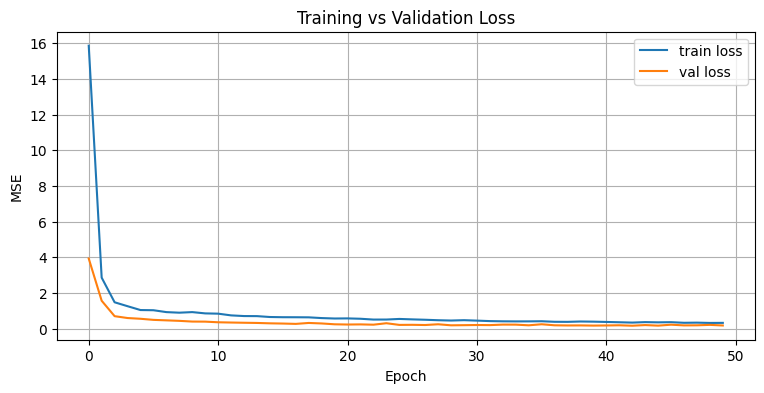

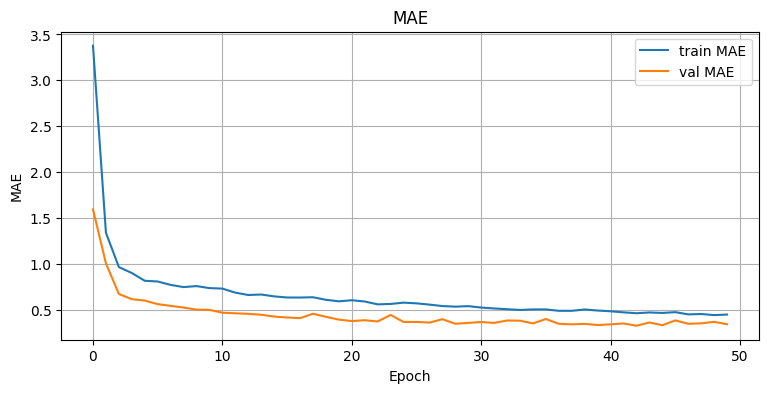

In [4]:
# Step 4: Visualize training curves

import matplotlib.pyplot as plt

# --- Plot Training vs Validation Loss ---
plt.figure(figsize=(9,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot Training vs Validation MAE ---
if 'mae' in history.history:
    plt.figure(figsize=(9,4))
    plt.plot(history.history['mae'], label='train MAE')
    plt.plot(history.history['val_mae'], label='val MAE')
    plt.title('MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
# -----------------------------
# ✅ Step 5 (Final Polished): Live input → predict → chart → hospital-style PDF
# -----------------------------
!apt-get install -y fonts-dejavu-core > /dev/null
!pip install fpdf2 --quiet

import joblib
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fpdf import FPDF, XPos, YPos
from datetime import date
from google.colab import files
import os

# --- Load scaler and model ---
scaler = joblib.load("mindenergy_scaler.pkl")
model = load_model("mindenergy_deep_model.h5", compile=False)
print("✅ Model loaded successfully (compile disabled)")

# --- User input ---
print("\n🏥 MindEnergy Wellness Prediction System\n")
name   = input("Enter patient name: ")
age    = float(input("Enter age (years): "))
bmi    = float(input("Enter BMI: "))
height = float(input("Enter height (m): "))
weight = float(input("Enter weight (kg): "))
sleep  = float(input("Average sleep hours: "))
steps  = float(input("Average steps per day: "))
screen = float(input("Average screen time (hours): "))
stress = float(input("Stress level (1–10): "))
mood   = float(input("Mood (1–10): "))
temp   = float(input("Temperature (°C): "))
hum    = float(input("Humidity (%): "))

# --- Prepare input ---
input_df = pd.DataFrame([[age, bmi, sleep, steps, screen, stress, mood, temp, hum]],
                        columns=['Age','BMI','SleepHrs','Steps','ScreenTime','Stress','Mood','Temp','Humidity'])
input_scaled = scaler.transform(input_df)

# --- Predict ---
pred = model.predict(input_scaled)[0]
energy, fatigue, depression = float(pred[0]), float(pred[1]), float(pred[2])
print(f"\nPredicted → Energy: {energy:.2f}, Fatigue: {fatigue:.2f}, Depression: {depression:.2f}")

# -----------------------------
# Create bar chart
# -----------------------------
labels = ["Energy", "Fatigue", "Depression"]
values = [max(0, energy), max(0, fatigue), max(0, depression)]
display_values = [min(v, 10) for v in values]
colors = ["#7AC87A", "#F4B942", "#E57373"]

plt.figure(figsize=(6,2.2))
bars = plt.barh(labels, display_values, color=colors, height=0.6)
plt.xlim(0, 10)
plt.xlabel("Score (0–10)")
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2 - 0.1,
             f"{values[i]:.2f}/10", va='center', fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
chart_path = "mindenergy_chart.png"
plt.savefig(chart_path, bbox_inches='tight', dpi=150)
plt.close()

# -----------------------------
# Generate hospital-style PDF
# -----------------------------
font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
bold_font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

out_name = f"MindEnergy_Report_{name.replace(' ','_')}.pdf"
pdf = FPDF()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)

# Register fonts
pdf.add_font("DejaVu", "", font_path)
pdf.add_font("DejaVu", "B", bold_font_path)

# Header
pdf.set_fill_color(30, 60, 120)
pdf.rect(0, 0, 210, 24, 'F')
pdf.set_text_color(255,255,255)
pdf.set_font("DejaVu", "B", 18)
pdf.cell(0, 13, "MindEnergy Wellness Report", align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.set_font("DejaVu", "", 10)
pdf.cell(0, 6, "Comprehensive Mental Wellness & Lifestyle Assessment", align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)

# 🟦 Added gap between header and info box
pdf.ln(12)

# Patient Info Box
pdf.set_fill_color(235, 245, 255)
pdf.set_draw_color(200,200,200)
pdf.rect(10, pdf.get_y(), 190, 30, 'FD')
pdf.set_xy(12, pdf.get_y()+2)
pdf.set_text_color(0,0,0)
pdf.set_font("DejaVu", "B", 12)
pdf.cell(0,6, f"Patient Name: {name}", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.set_font("DejaVu", "", 11)
pdf.cell(0,6, f"Age: {age:.1f} years     BMI: {bmi:.1f} kg/m\u00b2     Height: {height:.2f} m     Weight: {weight:.1f} kg", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.cell(0,6, f"Date: {date.today().strftime('%d-%b-%Y')}", new_x=XPos.LMARGIN, new_y=YPos.NEXT)

# Section 1: Mind-Energy Predictions
pdf.ln(10)
pdf.set_font("DejaVu", "B", 14)
pdf.set_text_color(10, 40, 120)
pdf.cell(0,8, "1. Mind-Energy Predictions", new_x=XPos.LMARGIN, new_y=YPos.NEXT)

pdf.ln(4)
pdf.set_font("DejaVu", "", 12)
y_before = pdf.get_y()
pdf.set_xy(18, y_before)
pdf.multi_cell(90, 6, f"Energy: {energy:.2f}/10\nFatigue: {fatigue:.2f}/10\nDepression: {depression:.2f}/10")
pdf.image(chart_path, x=110, y=y_before - 5, w=85)

# Section 2: Clinical Interpretation
pdf.ln(45)
pdf.set_font("DejaVu", "B", 14)
pdf.set_text_color(10, 40, 120)
pdf.cell(0,8, "2. Clinical Interpretation", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(2)
pdf.set_font("DejaVu", "", 11)
interpretation_lines = []

# BMI
if bmi < 18.5:
    interpretation_lines.append("- BMI: Underweight — consider nutrition support.")
elif bmi < 25:
    interpretation_lines.append("- BMI: Normal — maintain balanced diet and activity.")
elif bmi < 30:
    interpretation_lines.append("- BMI: Overweight — consider moderate exercise and dietary changes.")
else:
    interpretation_lines.append("- BMI: Obese — medical consultation recommended.")

# Energy
if energy < 4:
    interpretation_lines.append("- Low energy — prioritize sleep, hydration, and nutrient-rich meals.")
elif energy < 7:
    interpretation_lines.append("- Moderate energy — maintain good sleep hygiene and regular activity.")
else:
    interpretation_lines.append("- High energy — physical condition looks good; maintain habits.")

# Fatigue
if fatigue > 6:
    interpretation_lines.append("- Fatigue: high — take regular breaks; limit continuous screen use.")
elif fatigue > 3:
    interpretation_lines.append("- Fatigue: mild — monitor workload and rest.")

# Depression
if depression > 6:
    interpretation_lines.append("- Depression risk: elevated — consider counseling and social support.")
elif depression > 3:
    interpretation_lines.append("- Depression risk: mild — practice mindfulness and stress control.")
else:
    interpretation_lines.append("- Depression risk: low — continue healthy routines.")

for line in interpretation_lines:
    wrapped_lines = pdf.multi_cell(0, 7, line, align="L", split_only=True)
    for wrapped_line in wrapped_lines:
        pdf.multi_cell(0, 7, wrapped_line, align="L")
    pdf.ln(1.5)

# Section 3: Doctor's Notes
pdf.ln(6)
pdf.set_font("DejaVu", "B", 14)
pdf.set_text_color(10, 40, 120)
pdf.cell(0,8, "3. Doctor's Notes", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(2)
pdf.set_font("DejaVu", "", 11)
pdf.multi_cell(0,7,
"""This AI-generated assessment provides estimated indicators of mental and physical wellness.\nIt is not a diagnosis. Please consult a qualified healthcare professional for clinical evaluation.\nMaintain regular sleep, hydration, balanced meals, and mindful habits for sustained energy levels."""
)

# Footer
pdf.ln(6)
pdf.set_draw_color(200,200,200)
pdf.line(10, pdf.get_y(), 200, pdf.get_y())
pdf.ln(3)
pdf.set_font("DejaVu", "", 9)
pdf.set_text_color(110,110,110)
pdf.multi_cell(0,6,
    "Disclaimer: MindEnergy Report is AI-generated for informational purposes only. It is not a medical diagnosis or treatment recommendation."
)

pdf.output(out_name)
files.download(out_name)
print(f"\n✅ Report generated: {out_name}")

✅ Model loaded successfully (compile disabled)

🏥 MindEnergy Wellness Prediction System

Enter patient name: Uma
Enter age (years): 41
Enter BMI: 34
Enter height (m): 153
Enter weight (kg): 80
Average sleep hours: 6
Average steps per day: 500
Average screen time (hours): 5
Stress level (1–10): 8
Mood (1–10): 8
Temperature (°C): 37
Humidity (%): 83
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Predicted → Energy: 3.97, Fatigue: 6.71, Depression: 4.34


/tmp/ipykernel_1714/1417935030.py:162: DeprecationWarning: The parameter "split_only" is deprecated since v2.7.4. Use instead dry_run=True and output="LINES".
  wrapped_lines = pdf.multi_cell(0, 7, line, align="L", split_only=True)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Report generated: MindEnergy_Report_Uma.pdf
